In [403]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import LabelEncoder

import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set_theme()

# Q1

In [404]:
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "rkiattisak/salaly-prediction-for-beginer", "Salary Data.csv")
df.head()

/tmp/ipykernel_2719/1496768963.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "rkiattisak/salaly-prediction-for-beginer", "Salary Data.csv")


Using Colab cache for faster access to the 'salaly-prediction-for-beginer' dataset.


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [405]:
features = ['Years of Experience', 'Age', 'Education Level']
target = 'Salary'

In [406]:
le = LabelEncoder()
# This turns "Bachelor's", "Master's", "PhD" into integers like 0, 1, 2
df['Education Level'] = le.fit_transform(df['Education Level'])

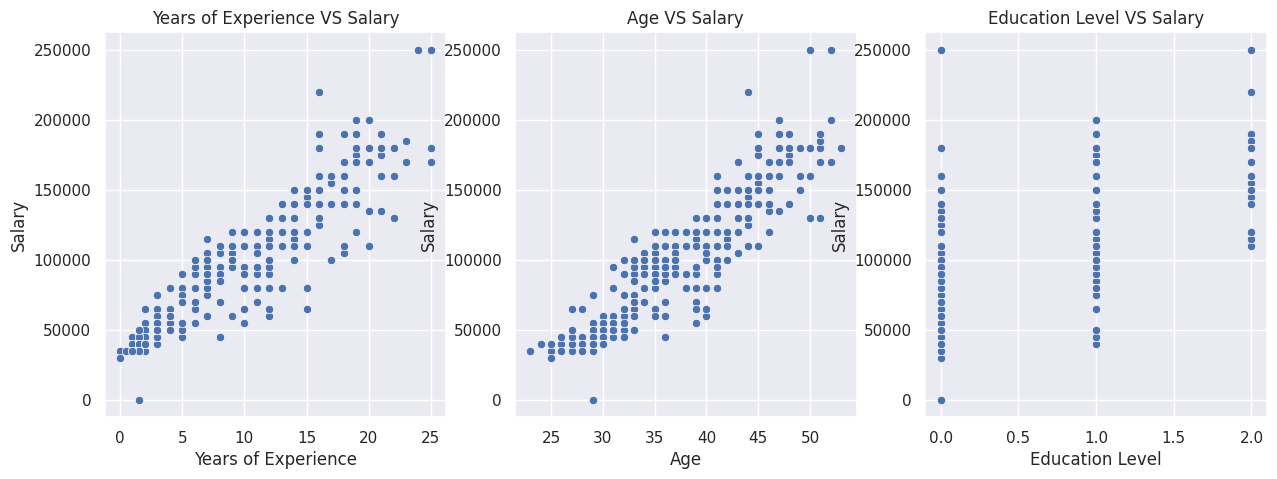

In [407]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


for i, feature in enumerate(features):
    sns.scatterplot(x=df[feature], y=df[target], ax=axes[i])
    axes[i].set_title(f'{feature} VS Salary')

plt.show()

In [408]:
corr_matrix = df[features + [target]].corr()
print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
                      Years of Experience       Age  Education Level    Salary
Years of Experience             1.000000  0.979128         0.590863  0.930338
Age                             0.979128  1.000000         0.562693  0.922335
Education Level                 0.590863  0.562693         1.000000  0.670371
Salary                          0.930338  0.922335         0.670371  1.000000


In [409]:
strongest_feature = corr_matrix[target].drop(target).idxmax()
print(f"The feature most strongly linearly correlated with Salary is: {strongest_feature}")

The feature most strongly linearly correlated with Salary is: Years of Experience


# Q2

In [410]:
X = np.array([
    [5, 7, 85],
    [3, 6, 70],
    [8, 8, 95],
    [2, 5, 60],
    [6, 7, 90],         # Row = 10, Feature = 3.
    [7, 8, 92],
    [4, 6, 75],
    [9, 7, 98],
    [1, 5, 50],
    [5, 6, 80]
])

In [411]:
y = np.array(
    [82, 65, 95, 55, 88, 90, 72, 98, 45, 78]
    )

In [412]:
def predict1(X, w, b):
    return X @ w + b  # @ = np.dot(X, w)

In [413]:
def predict2(X, w, b):
    return np.dot(X, w) + b

In [414]:
w = np.array([1, 1, 1])
b = 1.0

pred = predict1(X, w, b)
print(pred)

[ 98.  80. 112.  68. 104. 108.  86. 115.  57.  92.]


In [415]:
w = np.array([1, 1, 1])
b = 1.0

pred = predict2(X, w, b)
print(pred)

[ 98.  80. 112.  68. 104. 108.  86. 115.  57.  92.]


In [416]:
actual_w_was = np.array([82, 65, 95, 55, 88, 90, 72, 98, 45, 78])
print(actual_w_was)

[82 65 95 55 88 90 72 98 45 78]


# Q3.

In [417]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

In [418]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


##### Feature and Target

In [419]:
X = df[['MedInc', 'AveRooms', 'HouseAge']]
y = df['MedHouseVal']

##### Train Model


In [420]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

#####  Print Coefficients and Intercept

In [421]:
print(f"Coefficients : {model.coef_}")
print(f"Intercept : {model.intercept_}")

Coefficients : [ 0.4427634  -0.02715343  0.01682208]
Intercept : 0.020406956964582168


##### Display 5 sample predictions vs actuals

In [422]:
predictions = model.predict(X[:5])        # model's prediction method.
for i in range(5):
    print(f"Predicted: {predictions[i]:.3f}, Actual: {y.iloc[i]:.3f}")
for i in range(5):
    print(f"Predicted: {predictions[i]:.3f}, Actual: {y.iloc[i]:.3f}")

Predicted: 4.207, Actual: 4.526
Predicted: 3.880, Actual: 3.585
Predicted: 3.883, Actual: 3.521
Predicted: 3.236, Actual: 3.413
Predicted: 2.428, Actual: 3.422
Predicted: 4.207, Actual: 4.526
Predicted: 3.880, Actual: 3.585
Predicted: 3.883, Actual: 3.521
Predicted: 3.236, Actual: 3.413
Predicted: 2.428, Actual: 3.422


#Q4.

In [423]:
def compute_cost(X, y, w, b):
    m = len(y)
    y_pred = predict1(X, w, b)
    cost = (1/ (2 * m) * np.sum((y_pred - y) ** 2))
    return cost

In [424]:
compute_cost(X, y, w, b)

np.float64(754.887515750053)

##### Vary w[0] from -10 to +10 while keeping w[1], w[2], and b fixed

In [425]:
w_test = np.ones((3))
b_test = 1
w0_values = np.linspace(-10, 10, 100)
costs = []

for w0 in w0_values:
    w_test[0] = w0
    costs.append(compute_cost(X, y, w_test, b_test))


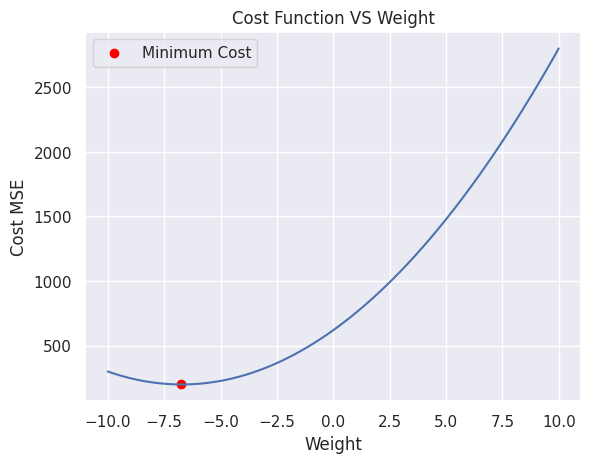

In [426]:
plt.plot(w0_values, costs)
plt.xlabel("Weight")
plt.ylabel("Cost MSE")
plt.title("Cost Function VS Weight")


# Mark Minimum

min_idx = np.argmin(costs) # min value's Index
plt.scatter(w0_values[min_idx], costs[min_idx], color='red', label='Minimum Cost')
plt.legend()
plt.show()

# Q5.

In [427]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [428]:
def gradient_descent(X, y, w, b, learning_rate=0.01, max_iter=1000):
    m = len(y)
    cost_history = []

    for i in range(max_iter):
        y_pred = predict1(X, w, b)
        error = y_pred - y
        dj_dw = (1/m) * X.T @ error
        dj_db = (1/m) * np.sum(error)

        w -= learning_rate * dj_dw
        b -= learning_rate * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i%100==0:
            print(f"iteration : {i} ---> Cost : {cost}")

    return w, b, cost_history

In [429]:
X = df[['TV', 'radio', 'newspaper']].values
y = df['sales'].values

In [430]:
# Feature Scaling (Crucial for learning_rate=0.01)
# Formula: (X - mean) / standard_deviation
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0) # Scaling

iteration : 0 ---> Cost : 109.63343927854163
iteration : 100 ---> Cost : 15.747631594807485
iteration : 200 ---> Cost : 3.3457231453700644
iteration : 300 ---> Cost : 1.6662958353031194
iteration : 400 ---> Cost : 1.4324485751872675
iteration : 500 ---> Cost : 1.3984804134285795
iteration : 600 ---> Cost : 1.3931982197393729
iteration : 700 ---> Cost : 1.3922904535547602
iteration : 800 ---> Cost : 1.3921141730666133
iteration : 900 ---> Cost : 1.392075615805127


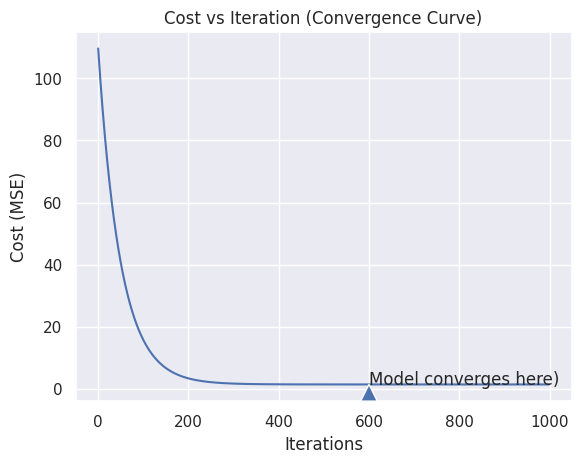

In [431]:
w_final, b_final, costs = gradient_descent(X, y, np.zeros(X.shape[1]), 0)
plt.plot(range(1000), costs) # max_iter
plt.title('Cost vs Iteration (Convergence Curve)')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')

plt.annotate('Model converges here)', xy=(600, costs[600]), arrowprops=dict())

plt.show()

# Q6.

In [432]:
!pip install ucimlrepo

In [433]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)

In [434]:

features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
X = df[feature_cols].values
y = df['Y1'].values


scaler = StandardScaler()
X = scaler.fit_transform(X)

In [435]:
# Linear Regression

lr_model = LinearRegression()
lr_model.fit(X, y)
prediction = lr_model.predict(X)
lr_mse = mean_squared_error(y, prediction)
print(lr_mse)


# SGD Regressor
sgd_model = SGDRegressor()
sgd_model.fit(X, y)
prediction = sgd_model.predict(X)
sgd_mse = mean_squared_error(y, prediction)
print(sgd_mse)

8.520534385774404
8.63428464289114


In [450]:
comparison_df = pd.DataFrame(
    {
        'Feature/Metric' : features +                           ['MSE'],
        'Linear Regression' : np.append(lr_model.coef_,         lr_mse),
        'SGD Regressor' : np.append(sgd_model.coef_,            sgd_mse)
    }
)

print("\n $ Model Comparison : \n\n")
print(comparison_df)


 $ Model Comparison : 


  Feature/Metric  Linear Regression  SGD Regressor
0             X1          -6.847108      -3.409547
1             X2          -3.766967      -1.376265
2             X3           0.711360       1.265538
3             X4          -4.016872      -1.953250
4             X5           7.297419       8.337581
5             X6          -0.026084      -0.024171
6             X7           2.653721       2.648143
7             X8           0.315844       0.305966
8            MSE           8.520534       8.634285


কেন SGDRegressor এর weights exact match করে না? (Why the weights differ):


Linear Regression OLS (Ordinary Least Squares) সমীকরণ ব্যবহার করে এক ধাপে exact mathematical minimum বের করে। অন্যদিকে, SGDRegressor র‍্যান্ডম ডেটা পয়েন্ট নিয়ে ধাপে ধাপে (iterative approach) error কমানোর চেষ্টা করে। যেহেতু এটি একটি approximation প্রসেস যা লার্নিং রেট এবং ইটারেশনের ওপর নির্ভরশীল, তাই এটি OLS-এর exact উত্তরের খুব কাছাকাছি পৌঁছালেও হুবহু একই ডেসিমাল ভ্যালুতে গিয়ে থামে না।  